#1 - Import Training, Validation Test Datas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import os, random, time, json

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print("All seeds set to", SEED)

All seeds set to 42


In [3]:
X_train = np.load("X_train.npy")
X_val   = np.load("X_val.npy")
X_test  = np.load("X_test.npy")
y_train = np.load("y_train.npy")
y_val   = np.load("y_val.npy")
y_test  = np.load("y_test.npy")

ACTIVITY_NAMES = [
    "Walking", "Walking Upstairs", "Walking Downstairs",
    "Sitting", "Standing", "Laying"
]

N_CLASSES   = 6
N_TIMESTEPS = 128
N_CHANNELS  = 9

print("X_train:", X_train.shape)
print("X_val:  ", X_val.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_val:  ", y_val.shape)
print("y_test: ", y_test.shape)

X_train: (6249, 128, 9)
X_val:   (1103, 128, 9)
X_test:  (2947, 128, 9)
y_train: (6249,)
y_val:   (1103,)
y_test:  (2947,)


#2 - Build CNN Model

In [4]:
from keras import Input
from keras.layers import Conv1D, MaxPooling1D, Activation, BatchNormalization, Dropout, GlobalAveragePooling1D, Dense

from keras import Model

from keras.optimizers import Adam

In [35]:
def build_model(learing_rate=0.001, unit_1 = 64, unit_2 = 128, unit_3 = 256, dropout = 0.4):

    # 1. INPUT LAYER
    inputs = Input(shape=(N_TIMESTEPS, N_CHANNELS))

    # 2. 1D CONV & 3. 1D POOL LAYERS (Block 1)
    x = Conv1D(filters=unit_1, kernel_size=3, padding="same")(inputs)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 2. 1D CONV & 3. 1D POOL LAYERS (Block 1)
    x = Conv1D(filters=unit_2, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 2. 1D CONV & 3. 1D POOL LAYERS (Block 1)
    x = Conv1D(filters=unit_3, kernel_size=3, padding="same")(x)
    x = BatchNormalization()(x)
    x = Activation("relu")(x)
    x = MaxPooling1D(pool_size=2)(x)

    # 4. FLATTEN LAYER ALTERNATIVE
    x = GlobalAveragePooling1D()(x)
    x = Dropout(dropout)(x)

    output = Dense(N_CLASSES, activation='softmax')(x)

    model = Model(inputs, output, name="CNN_1D")

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=Adam(learning_rate=learing_rate),
        metrics=["accuracy"]
    )

    return model

In [36]:
cnn_model = build_model()

In [37]:
cnn_model.summary()

Model: "CNN_1D"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 128, 9)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_12 (Conv1D)              │ (None, 128, 64)        │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 128, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_13 (Activation)      │ (None, 128, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_12 (MaxPooling1D) │ (None, 64, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_13 (Conv1D)              │ (None, 64, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 64, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 64, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_13 (MaxPooling1D) │ (None, 32, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_14 (Conv1D)              │ (None, 32, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 32, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 32, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_14 (MaxPooling1D) │ (None, 16, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d_4      │ (None, 256)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 128,390 (501.52 KB)

 Trainable params: 127,494 (498.02 KB)

 Non-trainable params: 896 (3.50 KB)

Input              : (128, 9)


---


After Conv1D(64)   : (128, 64)   — 128 timesteps, 64 feature maps


---


After MaxPool(2)   : (64, 64)    — sequence halved


---


After Conv1D(128)  : (64, 128)


---


After MaxPool(2)   : (32, 128)


---


After Conv1D(256)  : (32, 256)


---


After MaxPool(2)   : (16, 256)


---


After GlobalAvgPool: (256,)      — entire sequence collapsed to one vector


---
After Dense(6)     : (6,)        — one probability per class

In [38]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

In [39]:
earlyStopiing = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduceLR = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint_cb = ModelCheckpoint(
    filepath='cnn_model.keras',
    monitor='val_loss',
    mode='min',                     # 'min' for loss, 'max' for accuracy
    save_best_only=True,            # Only save when performance improves
    verbose=1
)

In [40]:
callbacks = [earlyStopiing, reduceLR, checkpoint_cb]

#3 - Train Model

In [57]:
start_time = time.time()

history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=200,
    batch_size=64,
    callbacks=callbacks,
    verbose=1
)

training_time = time.time() - start_time
print(f"\nTraining time: {training_time:.1f} seconds")

Epoch 1/200
92/98 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9997 - loss: 0.0034
Epoch 1: val_loss improved from 0.01354 to 0.01353, saving model to cnn_model.keras

Epoch 1: finished saving model to cnn_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9997 - loss: 0.0037 - val_accuracy: 0.9946 - val_loss: 0.0135 - learning_rate: 7.8125e-06
Epoch 2/200
95/98 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9994 - loss: 0.0050
Epoch 2: val_loss did not improve from 0.01353
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9990 - loss: 0.0048 - val_accuracy: 0.9946 - val_loss: 0.0136 - learning_rate: 7.8125e-06
Epoch 3/200
88/98 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0048
Epoch 3: val_loss improved from 0.01353 to 0.01353, saving model to cnn_model.keras

Epoch 3: finished saving model to cnn_model.keras
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9992 - loss: 0.0044 - val_accuracy: 0.9946 - val_loss: 0.0135 - learning_rate: 7.8125e-0

In [42]:
# Find the epoch with the lowest validation loss
best_epoch_index = np.argmin(history.history['val_loss'])

# Extract the metrics at that specific epoch
best_val_loss = history.history['val_loss'][best_epoch_index]
best_val_accuracy = history.history['val_accuracy'][best_epoch_index]

print("\n" + "="*40)
print(f"TRAINING COMPLETE - BEST METRICS FOUND:")
print(f"Best Epoch: {best_epoch_index + 1}") # +1 because epochs are 1-indexed in output but 0-indexed in arrays
print(f"Best Validation Loss: {best_val_loss:.4f}")
print(f"Best Validation Accuracy: {best_val_accuracy:.4f}")
print("="*40 + "\n")

# Verify the restored weights match by evaluating the model directly
print("Verifying restored weights on validation data:")
loss, acc = cnn_model.evaluate(X_val, y_val, verbose=0)
print(f"Evaluated Validation Loss: {loss:.4f}")
print(f"Evaluated Validation Accuracy: {acc:.4f}")


TRAINING COMPLETE - BEST METRICS FOUND:
Best Epoch: 136
Best Validation Loss: 0.0135
Best Validation Accuracy: 0.9946

Verifying restored weights on validation data:
Evaluated Validation Loss: 0.0135
Evaluated Validation Accuracy: 0.9946



TRAINING COMPLETE - BEST METRICS FOUND:

---


* Best Epoch: 136
* Best Validation Loss: 0.0135
* Best Validation Accuracy: 0.9946


---


* Verifying restored weights on validation data:
* Evaluated Validation Loss: 0.0135
* Evaluated Validation Accuracy: 0.9946

# 4 - Plot Comparisons

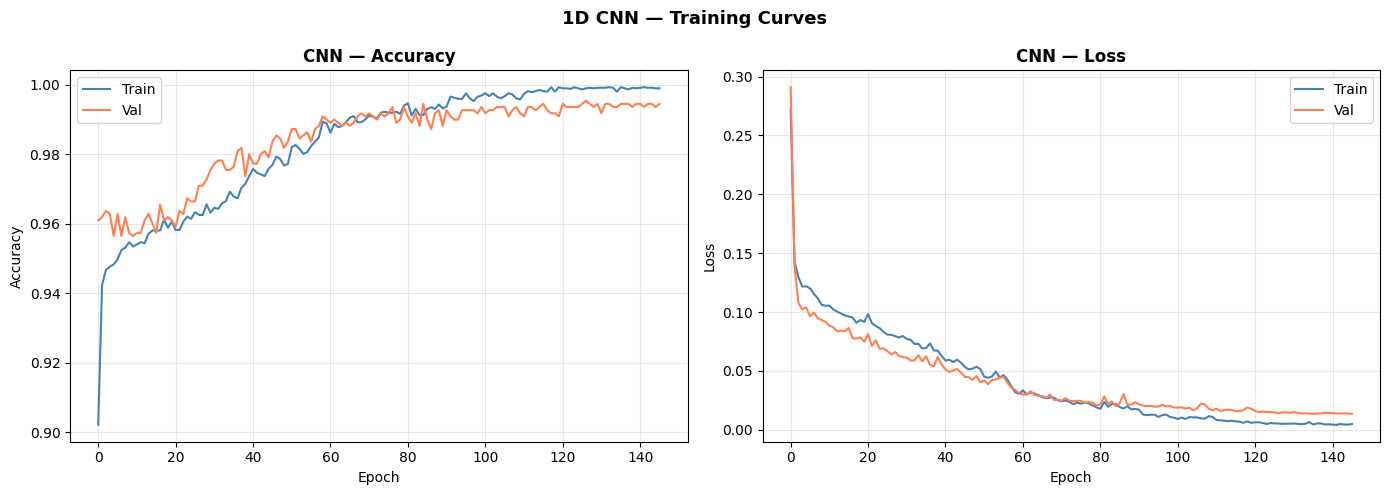

Best val_accuracy : 0.9955
Best val_loss     : 0.0135
Stopped at epoch  : 146


In [44]:
import os

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'],     label='Train', color='steelblue')
axes[0].plot(history.history['val_accuracy'], label='Val',   color='coral')
axes[0].set_title('CNN — Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history.history['loss'],     label='Train', color='steelblue')
axes[1].plot(history.history['val_loss'], label='Val',   color='coral')
axes[1].set_title('CNN — Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('1D CNN — Training Curves', fontsize=13, fontweight='bold')
plt.tight_layout()

# Fix: Create directory if it doesn't exist
os.makedirs('reports/figures', exist_ok=True)
plt.savefig('reports/figures/cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Best val_accuracy : {max(history.history['val_accuracy']):.4f}")
print(f"Best val_loss     : {min(history.history['val_loss']):.4f}")
print(f"Stopped at epoch  : {len(history.history['loss'])}")

In [48]:
from sklearn.metrics import classification_report, f1_score, confusion_matrix

In [49]:
y_pred_probs = cnn_model.predict(X_val)
y_pred       = np.argmax(y_pred_probs, axis=1)

val_accuracy = np.mean(y_pred == y_val)
val_f1_macro = f1_score(y_val, y_pred, average='macro')

print(f"Validation Accuracy : {val_accuracy:.4f}")
print(f"Validation Macro F1 : {val_f1_macro:.4f}")
print()
print(classification_report(y_val, y_pred, target_names=ACTIVITY_NAMES))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Validation Accuracy : 0.9946
Validation Macro F1 : 0.9950

                    precision    recall  f1-score   support

           Walking       1.00      1.00      1.00       184
  Walking Upstairs       1.00      1.00      1.00       161
Walking Downstairs       1.00      1.00      1.00       148
           Sitting       0.98      0.99      0.98       193
          Standing       0.99      0.98      0.99       206
            Laying       1.00      1.00      1.00       211

          accuracy                           0.99      1103
         macro avg       0.99      1.00      0.99      1103
      weighted avg       0.99      0.99      0.99      1103



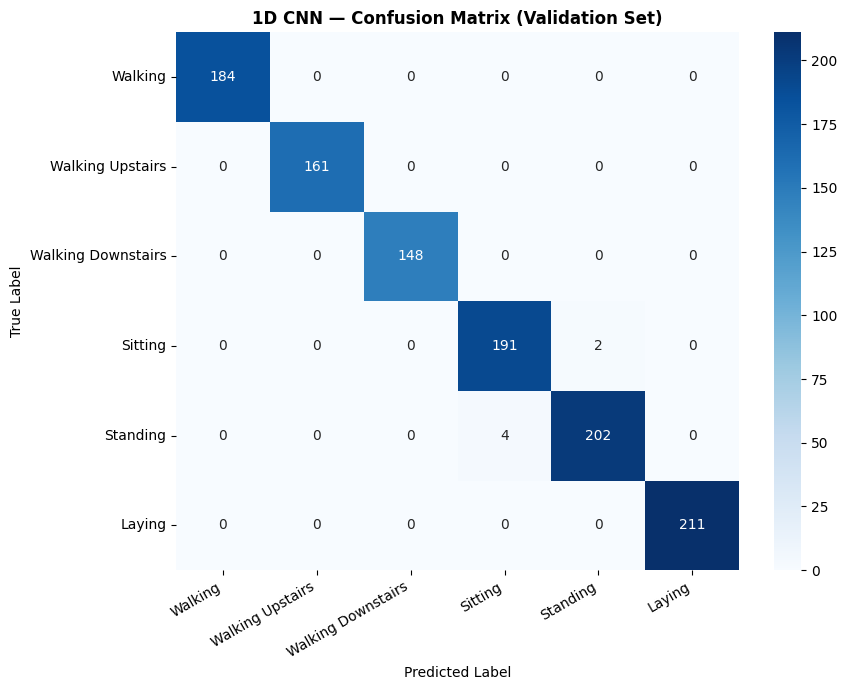

In [50]:
cm = confusion_matrix(y_val, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITY_NAMES,
            yticklabels=ACTIVITY_NAMES)
plt.title('1D CNN — Confusion Matrix (Validation Set)',
          fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('reports/figures/cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

#5 - Save CNN Model

In [51]:
cnn_results = {
    "model"            : "CNN_1D",
    "total_params"     : cnn_model.count_params(),
    "val_accuracy"     : round(float(val_accuracy), 4),
    "val_f1_macro"     : round(float(val_f1_macro), 4),
    "training_time"    : round(training_time, 1),
    "epochs_run"       : len(history.history['loss']),
    "train_acc_curve"  : [round(v, 4) for v in history.history['accuracy']],
    "val_acc_curve"    : [round(v, 4) for v in history.history['val_accuracy']],
    "train_loss_curve" : [round(v, 4) for v in history.history['loss']],
    "val_loss_curve"   : [round(v, 4) for v in history.history['val_loss']],
}

os.makedirs("artifacts/results", exist_ok=True)
with open("artifacts/results/cnn_results.json", "w") as f:
    json.dump(cnn_results, f, indent=2)

print("Results saved to artifacts/results/cnn_results.json")
print()
print("=" * 45)
print("1D CNN SUMMARY")
print("=" * 45)
print(f"Total Parameters : {cnn_model.count_params():,}")
print(f"Val Accuracy     : {val_accuracy:.4f}")
print(f"Val Macro F1     : {val_f1_macro:.4f}")
print(f"Training Time    : {training_time:.1f}s")
print(f"Epochs Run       : {len(history.history['loss'])}")
print("=" * 45)

Results saved to artifacts/results/cnn_results.json

1D CNN SUMMARY
Total Parameters : 128,390
Val Accuracy     : 0.9946
Val Macro F1     : 0.9950
Training Time    : 107.7s
Epochs Run       : 146


In [53]:
import os

# Ensure the directory exists before saving
os.makedirs("artifacts/models/", exist_ok=True)

cnn_model.save("artifacts/models/cnn_best.keras")
print("Model saved to artifacts/models/cnn_best.keras")

Model saved to artifacts/models/cnn_best.keras


In [56]:
from tensorflow.keras.models import load_model

# Load the saved model
loaded_model = load_model('artifacts/models/cnn_best.keras')

# Evaluate on test data to verify
test_loss, test_acc = loaded_model.evaluate(X_test, y_test, verbose=1)

print(f"\n[Verification] Loaded Model Test Accuracy: {test_acc:.4f}")
print(f"[Verification] Loaded Model Test Loss:     {test_loss:.4f}")

93/93 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9420 - loss: 0.5390

[Verification] Loaded Model Test Accuracy: 0.9420
[Verification] Loaded Model Test Loss:     0.5390


* CNN — Parameters   : 127,494
* CNN — Val Accuracy : 0.9946  (99.46%)
* CNN — Macro F1     : 0.9950  (99.50%)
* CNN — Best Epoch   : 136
* CNN — Training Time: 107.7s